In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(

In [4]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

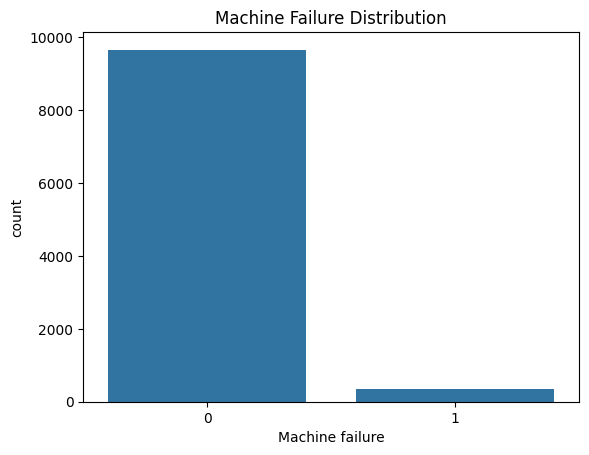

In [5]:
sns.countplot(x=df['Machine failure'])
plt.title("Machine Failure Distribution")
plt.show()

In [6]:
window_size = 5

df['air_temp_roll_mean'] = (
    df['Air temperature [K]']
    .rolling(window=window_size)
    .mean()
)

df['process_temp_roll_std'] = (
    df['Process temperature [K]']
    .rolling(window=window_size)
    .std()
)

df['torque_roll_var'] = (
    df['Torque [Nm]']
    .rolling(window=window_size)
    .var()
)

In [7]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,air_temp_roll_mean,process_temp_roll_std,torque_roll_var
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,NaN,NaN,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,NaN,NaN,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,298.16,0.083666,17.835
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0,298.16,0.083666,18.357
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0,298.14,0.070711,15.783
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0,298.14,0.044721,1.615
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0,298.16,0.054772,32.462
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0,298.22,0.173205,52.982
